In [17]:
import keras
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import tensorflow as tf
from tensorflow import keras

Este jupytrer es para probar la funcion de la red que sintetiza el audio y ver que este todo en orden.

Lo que tiene que hacer es:

1.- 

In [3]:
def additive_synth(f0, loudness, harmonics, noise):
    """
    f0:     (B, T, 1)
    loud:   (B, T, 1)
    harm:   (B, T, K)
    noise:  (B, T, 65)
    Devuelve: audio (B, N)
    """
    B = tf.shape(f0)[0]
    T = tf.shape(f0)[1]
    K = tf.shape(harmonics)[2]
    N = 64000
    sr = 16000
    # Upsampling a tasa de audio (ceil y recorte a N para evitar supuestos)
    reps = tf.cast(tf.math.ceil(tf.cast(N, tf.float32) / tf.cast(T, tf.float32)), tf.int32)
    f0_up   = tf.repeat(f0,   repeats=reps, axis=1)[:, :N, :]        # (B,N,1)
    loud_up = tf.repeat(loudness, repeats=reps, axis=1)[:, :N, :]    # (B,N,1)
    harm_up = tf.repeat(harmonics, repeats=reps, axis=1)[:, :N, :]   # (B,N,K)
    noise_up = tf.repeat(noise, repeats=reps, axis=1)[:, :N, :]     # (B,N,65)
    # Fase acumulada: phi[n] = sum_{m<=n} 2*pi*f0[m]/fs
    omega = 2.0 * tf.constant(np.pi, tf.float32) * f0_up[..., 0] / float(sr)  # (B,N)
    phi = tf.cumsum(omega, axis=1)                                   # (B,N)
    phi = phi[:, :, tf.newaxis]                                      # (B,N,1)
    # Índices de armónicos k = 1..K
    ks = tf.reshape(tf.range(1, tf.cast(K, tf.int32) + 1, dtype=tf.float32), (1, 1, -1))  # (1,1,K)
    # Señal por armónico y suma final
    phase = phi * ks                             # (B,N,K)
    sig = loud_up * harm_up * tf.sin(phase)     # (B,N,K)
    audio_harm = tf.reduce_sum(sig, axis=-1)         # (B,N)
    # Ruido
    # --- Parámetros básicos ---
    frame_length = 512     # igual o menor que 1024 (STFT)
    frame_step   = 256     # hop de 256 muestras
    n_fft_bins   = 65      # igual que la salida del decoder
    n_frames_est = tf.cast(tf.math.ceil(tf.cast(N, tf.float32) / frame_step), tf.int32)
    # --- Ruido blanco (B, N) ---
    white = tf.random.uniform(tf.shape(audio_harm), -1.0, 1.0)
    # --- STFT del ruido (B, F, T) ---
    noise_stft = tf.signal.stft(
        white,
        frame_length=frame_length,
        frame_step=frame_step,
        fft_length=frame_length,
        window_fn=tf.signal.hann_window,
        pad_end=True
    )  # (B, F, T)
    mag = tf.abs(noise_stft)
    phase = tf.math.angle(noise_stft)
    F = tf.shape(mag)[1]
    T_frames = tf.shape(mag)[2]
    # --- Filtro del decoder ---
    # Ajustamos el tamaño temporal (interpolación si hace falta)
    noise_t = noise  # (B, T_feat, 65)
    noise_t = tf.image.resize(noise_t[..., tf.newaxis], [T_frames, n_fft_bins], method='bilinear')[..., 0]
    # Normalizar el filtro y expandir a los bins reales de la FFT
    filt = noise_t / (1e-6 + tf.reduce_max(noise_t, axis=-1, keepdims=True))  # (B, T_frames, 65)
    filt = tf.transpose(filt, perm=[0, 2, 1])  # (B, 65, T_frames)
    filt = tf.image.resize(filt[..., tf.newaxis], [F, T_frames], method='bilinear')[..., 0]  # (B, F, T)
    # --- Aplicar magnitud del filtro ---
    mag_filtered = mag * filt
    # --- Reconstrucción del espectro complejo ---
    noise_stft_filt = tf.complex(mag_filtered * tf.cos(phase), mag_filtered * tf.sin(phase))
    # --- Inversa de STFT (reconstrucción temporal) ---
    noise_filtered = tf.signal.inverse_stft(
        noise_stft_filt,
        frame_length=frame_length,
        frame_step=frame_step,
        window_fn=tf.signal.hann_window
    )  # (B, N')
    # Recortar/padear a longitud exacta
    Nf = tf.shape(noise_filtered)[1]
    noise_filtered = tf.cond(
        Nf < N,
        lambda: tf.pad(noise_filtered, [[0,0],[0, N - Nf]]),
        lambda: noise_filtered[:, :N]
    )
    # --- Normalizar y combinar ---
    noise_filtered = noise_filtered / (1e-6 + tf.reduce_max(tf.abs(noise_filtered), axis=1, keepdims=True))
    audio = audio_harm + 0.05 * noise_filtered
    audio = audio / (1e-6 + tf.reduce_max(tf.abs(audio), axis=1, keepdims=True))
    return audio, audio_harm, noise_filtered

# Resample de audio y guardar

In [15]:
import scipy.io.wavfile as wav
import librosa
import soundfile as sf

fs, data = wav.read("Solo_DPA_10.wav")

print("frecuencia de muestreo: ", fs)
print("numero de muestras; ", len(data))
print("duracion: ", len(data)/fs, "segundos")
print("Data type:", data.dtype)

frecuencia de muestreo:  44100
numero de muestras;  2024341
duracion:  45.90342403628118 segundos
Data type: int16


La gracia de librosa es que al abrir el archivo lo convierte a float 32 y lo escala a [-1,1]

In [13]:
data, sr = librosa.load("Solo_DPA_10.wav", sr = 44100)

sr_new = 16000

audio_resampled = librosa.resample(data, orig_sr= sr, target_sr=sr_new)

sf.write("Solo_DPA_10_16000.wav", audio_resampled, sr_new)

# Sacar el loudness

Esto es STFT -> |.|^2 ->  A-weighting -> log10 -> norm

(1025, 11476)
FFT por muestra:  1025
cantidad de ventanas de tiempo:  11476
(1025, 11476)


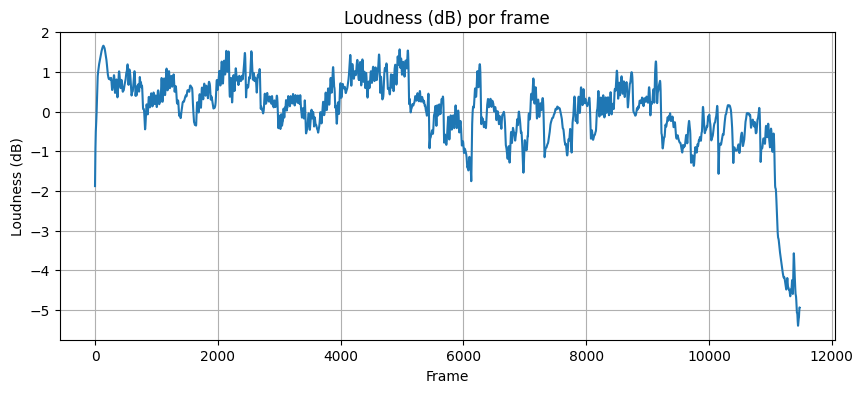

In [51]:
data, sr = librosa.load("Solo_DPA_10_16000.wav", sr = 16000)

n_fft = 2048
hop_length = 64

stft = librosa.core.stft(data, hop_length= hop_length, n_fft=n_fft)
potencia = np.abs(stft)**2
print(potencia.shape)
print("FFT por muestra: ", potencia.shape[0])
print("cantidad de ventanas de tiempo: ", potencia.shape[1])
freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

############# aca defino A-weighting ##################
def a_weighting(f):
    f = np.array(f)
    ra = (12200**2 * f**4) / (
        (f**2 + 20.6**2)
        * np.sqrt((f**2 + 107.7**2) * (f**2 + 737.9**2))
        * (f**2 + 12200**2)
    )
    A = 20 * np.log10(ra + 1e-12) + 2.0  # +2 dB para normalizar a 0 dB en 1 kHz
    return A
###########################################################
A_dB = a_weighting(freqs)
A_lin = 10 ** (A_dB / 20)

#aca aplico A-weighting 
power_A = potencia * A_lin[:, np.newaxis]
print(power_A.shape)



loudness_db = 10 * np.log10(np.mean(power_A, axis=0) + 1e-12)
loudness_db = (loudness_db - np.mean(loudness_db))/np.std(loudness_db)


plt.figure(figsize=(10, 4))
plt.plot(loudness_db)
plt.title("Loudness (dB) por frame")
plt.xlabel("Frame")
plt.ylabel("Loudness (dB)")
plt.grid()
plt.show()

# Sacar f_0 
esta parte es bien simple, todo la ventana y calculo el argmax

(11476,)
(11476,)


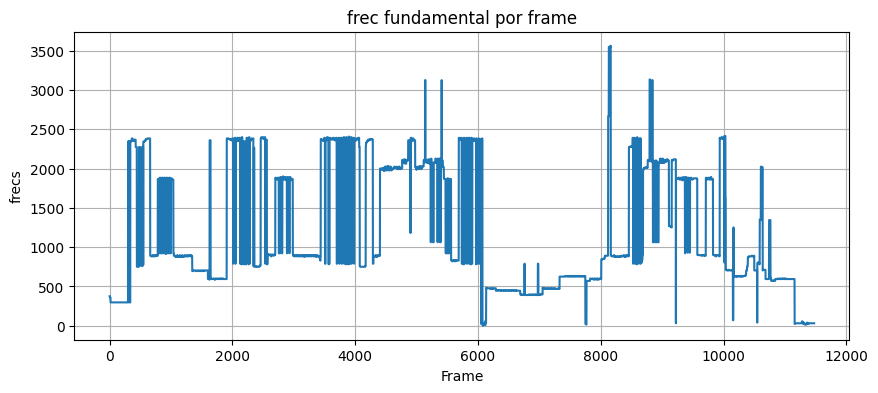

In [62]:
stft = np.abs(stft)

indices = np.argmax(stft, axis=0)
print(indices.shape)

f0_n = freqs[indices]

print(f0_n.shape)
plt.figure(figsize=(10, 4))
plt.plot(f0_n)
plt.title("frec fundamental por frame")
plt.xlabel("Frame")
plt.ylabel("frecs")
plt.grid()
plt.show()

11476


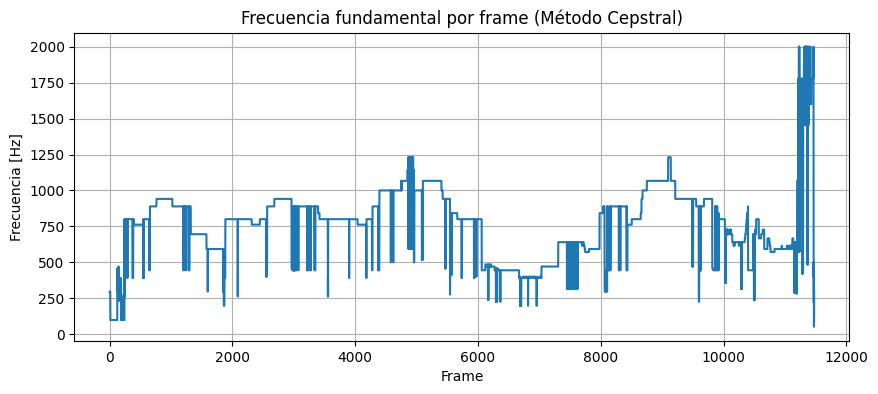

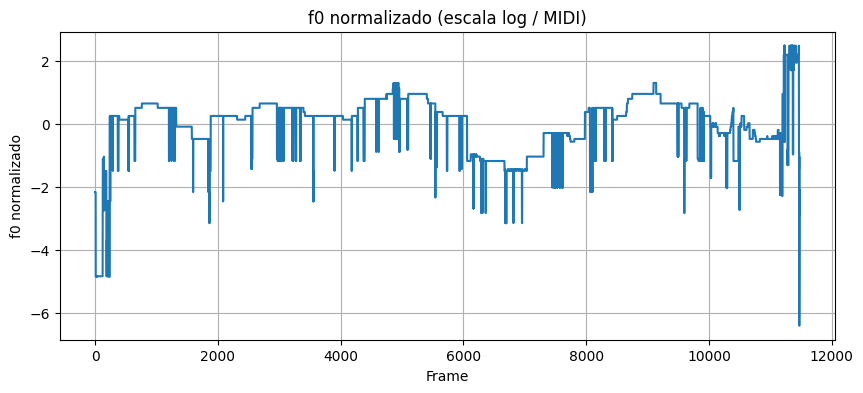

(11476,)


In [69]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

def f0_cepstrum(x, sr, frame_length=2048, hop_length=64, fmin=50, fmax=2000):
    """
    Estimación de f0 por método cepstral (por frames).
    """
    n_frames =  (len(x)) // hop_length +1
    print(n_frames)
    f0s = []

    for i in range(n_frames):
        start = i * hop_length
        frame = x[start:start + frame_length]
        #if len(frame) < frame_length:
        #    break

        # ventana Hamming
        frame = frame * np.hamming(len(frame))
        # FFT y magnitud logarítmica
        spectrum = np.fft.rfft(frame)
        log_mag = np.log(np.abs(spectrum) + 1e-10)

        # Cepstrum (FFT inversa del log espectro)
        cepstrum = np.fft.irfft(log_mag)

        # rango plausible de quefrencias (periodos)
        qmin = int(sr / fmax)
        qmax = int(sr / fmin)

        # buscar máximo en ese rango
        peak_index = np.argmax(cepstrum[qmin:qmax]) + qmin
        f0 = sr / peak_index
        f0s.append(f0)

    return np.array(f0s)

# === Uso ===
data, sr = librosa.load("Solo_DPA_10_16000.wav", sr=16000)
f0_n = f0_cepstrum(data, sr)

# === Normalización tipo DDSP (opcional) ===
f0_midi = 69 + 12 * np.log2(f0_n / 440.0)
f0_norm = (f0_midi - np.mean(f0_midi)) / np.std(f0_midi)

# === Gráficos ===
plt.figure(figsize=(10,4))
plt.plot(f0_n)
plt.title("Frecuencia fundamental por frame (Método Cepstral)")
plt.xlabel("Frame")
plt.ylabel("Frecuencia [Hz]")
plt.grid()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(f0_norm)
plt.title("f0 normalizado (escala log / MIDI)")
plt.xlabel("Frame")
plt.ylabel("f0 normalizado")
plt.grid()
plt.show()

print(f0_norm.shape)